In [1]:
from TKA_JGA_Mo_250111_ import calc_eq, dfg, phi_Soave, delta_f_G
import numpy as np
import matplotlib.pyplot as plt

-228574.720398674
-219037.98663425655
-237242.7116479068


## Alvarez 2017: here also these jumps seeable

In [2]:
print(dfg(298.15)[2])
print(dfg(500)[2])

-227942.24398134253
-218243.9520016743


In [3]:
T = np.linspace(100, 400, 150) + 273.15
p = np.array(([1, 10, 30, 50, 100])) * 1e5
x_0 = np.array([
    0.25, # CO2
    0.75-5e-20, # H2
    1e-20, # H2O
    1e-20,
    1e-20,
    1e-20,
    1e-20,
    1e-20,
])

In [5]:
counter = 0
x_eq = np.zeros((len(p), len(T), len(x_0)))
X_CO2 = np.zeros((len(p), len(T)))
S_MeOH = np.zeros((len(p), len(T)))
for i in range(len(p)):
    for j in range(len(T)):
        x_eq[i, j, :], succ, g_T_val, n_eq_val = calc_eq(T[j], p[i], x_0, 'real gas')
        X_CO2[i, j] = (x_0[0] - n_eq_val[0]) / x_0[0]
        S_MeOH[i, j] = - ((x_0[4] + x_0[-1]) - (n_eq_val[4] + n_eq_val[-1])) / (x_0[0] - n_eq_val[0])

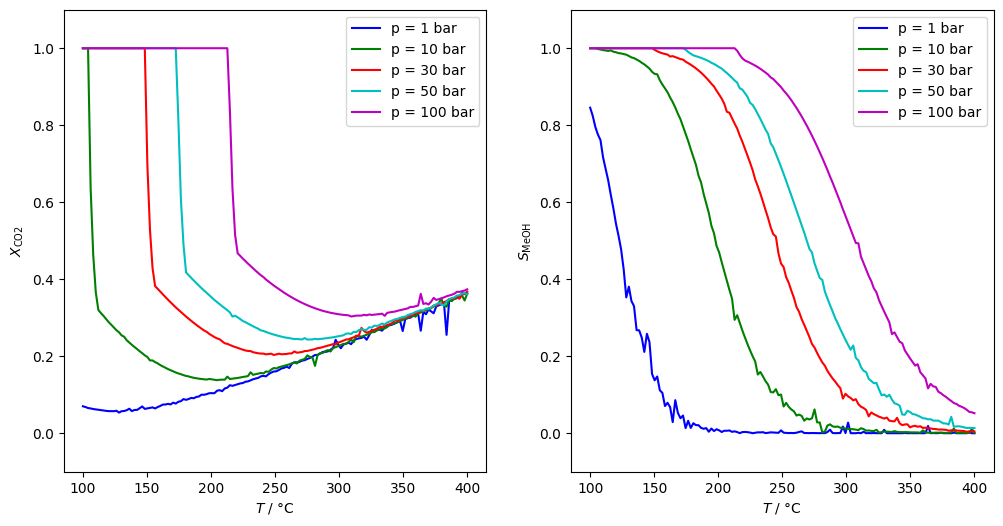

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))


species = ['CO2', 'H2', 'H2O', 'CO', 'MeOH', 'N2']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']

for j in range(len(p)):
    #plt.plot(T-273.15, x_eq[0, :, j], label=species[j], color=colors[j])
    # plot X_CO2
    ax[0].plot(T-273.15, X_CO2[j, :], label=f'p = {p[j]/1e5:.0f} bar', color=colors[j])
    # plot S_MeOH
    ax[1].plot(T-273.15, S_MeOH[j, :], label=f'p = {p[j]/1e5:.0f} bar', color=colors[j])

ax[0].set_xlabel(r'$T$ / °C')
ax[1].set_xlabel(r'$T$ / °C')
ax[0].set_ylim(-0.1, 1.1)
ax[1].set_ylim(-0.1, 1.1)
ax[0].set_ylabel(r'$X_{\mathrm{CO2}}$')
ax[1].set_ylabel(r'$S_{\mathrm{MeOH}}$')
ax[0].legend()
ax[1].legend()
plt.show()